In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

import re

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.model_selection import GridSearchCV
import pickle
import os
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight


In [4]:
#ruta donde se encuentra el dataset

In [8]:
ruta='C:/Users/Vanina/Documents/tesis/Datos/predictivo/'


### Lee dataset

In [9]:
df = pd.read_csv(ruta+'procesos2016_2022_nuevas_var_disc_ipc.csv', sep='|',low_memory=False)

In [10]:
metricas = pd.read_csv(ruta+'proceso_propiedades_grafo.csv', sep=',',low_memory=False);

### Se construye el target

In [11]:
#construir la clase
#si el estado es Adjudicado, el proceso es exitoso, clase es 1
#si el estado es Desierto ó Dejado Sin Efecto, es no exitoso, clase es 0

df["targetB"] = (df["estado"] != "Adjudicado").astype(int)
# Crear el mapeo de estados a números
mapa_target = {
    "Adjudicado": 0,
    "Desierto": 1,
    "Dejado Sin Efecto": 2
}

# Crear la variable target usando map()
df["target"] = df["estado"].map(mapa_target)

### Se arman datasets con variables numéricas y catrgóricas separadas para analizar correlaciones entre variables

In [12]:
#se seleccionan las variables a utilizar del dataset
df=df[['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','periodo_apertura','periodo_publicacion','periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura','dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias','cat_inicio_contrato','cant_total_bienes','cant_total_servicios','tipo_adquisicion','TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER',
'TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION',
'TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS',
'TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA','P_monto_total_procesos','P_cant_proveedores',
'd_proveedores_participantes','d_ofertas_confirmadas','d_dias_recepcion_doc_soporte_fisico','d_cant_total_bienes','d_cant_total_servicios','dP_monto_total_procesos','dP_cant_proveedores','d_duracion_contrato_dias','target','targetB'
]]

In [13]:
#para las variables numéricas, se reemplaza el valor 'sin datos' por nulo y se transforman en numéricas en caso de der objetc.

df.loc[:, 'cro_cant_dias_publicar'] = pd.to_numeric(df['cro_cant_dias_publicar'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'proveedores_participantes'] = pd.to_numeric(df['proveedores_participantes'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'ofertas_confirmadas'] = pd.to_numeric(df['ofertas_confirmadas'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_apertura'] = pd.to_numeric(df['periodo_apertura'].replace("sin datos",0), errors='coerce')
df.loc[:, 'periodo_publicacion'] = pd.to_numeric(df['periodo_publicacion'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_inicio_consultas'] = pd.to_numeric(df['periodo_inicio_consultas'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_final_consultas'] = pd.to_numeric(df['periodo_final_consultas'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_inicio_recepcion_documentos'] = pd.to_numeric(df['periodo_inicio_recepcion_documentos'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_fin_recepcion_documentos'] = pd.to_numeric(df['periodo_fin_recepcion_documentos'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'periodo_acto_apertura'] = pd.to_numeric(df['periodo_acto_apertura'].replace("sin datos", 0), errors='coerce')
df.loc[:, 'dias_recepción_doc_soporte_fisico'] = pd.to_numeric(df['dias_recepción_doc_soporte_fisico'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'duracion_contrato_dias'] = pd.to_numeric(df['duracion_contrato_dias'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'P_monto_total_procesos'] = pd.to_numeric(df['P_monto_total_procesos'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'P_cant_proveedores'] = pd.to_numeric(df['P_cant_proveedores'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'cant_total_bienes'] = pd.to_numeric(df['cant_total_bienes'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'cant_total_servicios'] = pd.to_numeric(df['cant_total_servicios'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_AGROPECUARIO'] = pd.to_numeric(df['TOT_AGROPECUARIO'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_ALIMENTOS'] = pd.to_numeric(df['TOT_ALIMENTOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_ALQUILER'] = pd.to_numeric(df['TOT_ALQUILER'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_ART_HOGAR'] = pd.to_numeric(df['TOT_ART_HOGAR'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_BANCO'] = pd.to_numeric(df['TOT_BANCO'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_BAZAR'] = pd.to_numeric(df['TOT_BAZAR'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CARPINTERIA'] = pd.to_numeric(df['TOT_CARPINTERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CEREMONIAL'] = pd.to_numeric(df['TOT_CEREMONIAL'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CERRAJERIA'] = pd.to_numeric(df['TOT_CERRAJERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CINE'] = pd.to_numeric(df['TOT_CINE'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_COMBUSTIBLES'] = pd.to_numeric(df['TOT_COMBUSTIBLES'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CONCESION'] = pd.to_numeric(df['TOT_CONCESION'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CONSTRUCCION'] = pd.to_numeric(df['TOT_CONSTRUCCION'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_CULTURA'] = pd.to_numeric(df['TOT_CULTURA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_ELECTRICIDAD'] = pd.to_numeric(df['TOT_ELECTRICIDAD'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_LIMPIEZA'] = pd.to_numeric(df['TOT_LIMPIEZA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_MUEBLES'] = pd.to_numeric(df['TOT_MUEBLES'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_EQUIPO_MILITAR'] = pd.to_numeric(df['TOT_EQUIPO_MILITAR'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_EQUIPOS'] = pd.to_numeric(df['TOT_EQUIPOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_FERRETERIA'] = pd.to_numeric(df['TOT_FERRETERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_GASES_IND'] = pd.to_numeric(df['TOT_GASES_IND'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_HERRAMIENTAS'] = pd.to_numeric(df['TOT_HERRAMIENTAS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_HERRERIA'] = pd.to_numeric(df['TOT_HERRERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_IMPRENTA'] = pd.to_numeric(df['TOT_IMPRENTA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_INDUMENTARIA'] = pd.to_numeric(df['TOT_INDUMENTARIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_INFORMATICA'] = pd.to_numeric(df['TOT_INFORMATICA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_INMUEBLES'] = pd.to_numeric(df['TOT_INMUEBLES'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_INSUMO_ARMAMENTO'] = pd.to_numeric(df['TOT_INSUMO_ARMAMENTO'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_JOYERIA'] = pd.to_numeric(df['TOT_JOYERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_LIBRERIA'] = pd.to_numeric(df['TOT_LIBRERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_MANTENIMIENTO'] = pd.to_numeric(df['TOT_MANTENIMIENTO'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_METALES'] = pd.to_numeric(df['TOT_METALES'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_METALURGIA'] = pd.to_numeric(df['TOT_METALURGIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_NAUTICA'] = pd.to_numeric(df['TOT_NAUTICA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_PINTURAS'] = pd.to_numeric(df['TOT_PINTURAS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_PROD_MEDICOS'] = pd.to_numeric(df['TOT_PROD_MEDICOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_PROD_VETERINARIOS'] = pd.to_numeric(df['TOT_PROD_VETERINARIOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_QUIMICOS'] = pd.to_numeric(df['TOT_QUIMICOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_REPUESTOS'] = pd.to_numeric(df['TOT_REPUESTOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_PLOMERIA'] = pd.to_numeric(df['TOT_PLOMERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_SERV_PROFESIONAL'] = pd.to_numeric(df['TOT_SERV_PROFESIONAL'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_SERV_NOTICIAS'] = pd.to_numeric(df['TOT_SERV_NOTICIAS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_SERV_BASICOS'] = pd.to_numeric(df['TOT_SERV_BASICOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_TAPICERIA'] = pd.to_numeric(df['TOT_TAPICERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_TRANSPORTE'] = pd.to_numeric(df['TOT_TRANSPORTE'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_PROD_DEPORTIVOS'] = pd.to_numeric(df['TOT_PROD_DEPORTIVOS'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_VIDRIERIA'] = pd.to_numeric(df['TOT_VIDRIERIA'].replace("sin datos", np.nan), errors='coerce')
df.loc[:, 'TOT_VIGILANCIA'] = pd.to_numeric(df['TOT_VIGILANCIA'].replace("sin datos", np.nan), errors='coerce')

In [14]:
def limpiar_numero(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["sin datos", "-", "", "nan"]:
        return np.nan   
    x = re.sub(r"[^\d.]", "", x)   # elimina letras y símbolos
    return pd.to_numeric(x, errors="coerce")

In [15]:
df_num_sin_tot=df[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','periodo_apertura','periodo_publicacion','periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura','dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias','P_monto_total_procesos','P_cant_proveedores','cant_total_bienes','cant_total_servicios','target','targetB']].map(limpiar_numero)

In [16]:
#se arma el dataset sólo con las variables numéricas 
df_num_tot=df[['TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER',
'TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION',
'TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS',
'TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA','target','targetB']].map(limpiar_numero)

In [17]:
#se arma el dataset sólo con las variables numéricas 
df_num=df[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','periodo_apertura','periodo_publicacion','periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura','dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias','P_monto_total_procesos','P_cant_proveedores','cant_total_bienes','cant_total_servicios','TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER',
'TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION',
'TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS',
'TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA','target','targetB']].map(limpiar_numero)

In [18]:
#se arma el dataset solo con variables categóricas 
df_cat = df[['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion','d_proveedores_participantes','d_ofertas_confirmadas','d_dias_recepcion_doc_soporte_fisico','d_cant_total_bienes','d_cant_total_servicios','dP_monto_total_procesos','dP_cant_proveedores','d_duracion_contrato_dias']]

In [19]:
# Contar cuántos casos hay en cada clase del target
conteo = df["target"].value_counts()
conteo

target
0    54562
2    13428
1     1696
Name: count, dtype: int64

### Matriz de Correlación 

#### Variables numéricas sin incluir totales por rubro (se divide para que el gráfico sea legible)

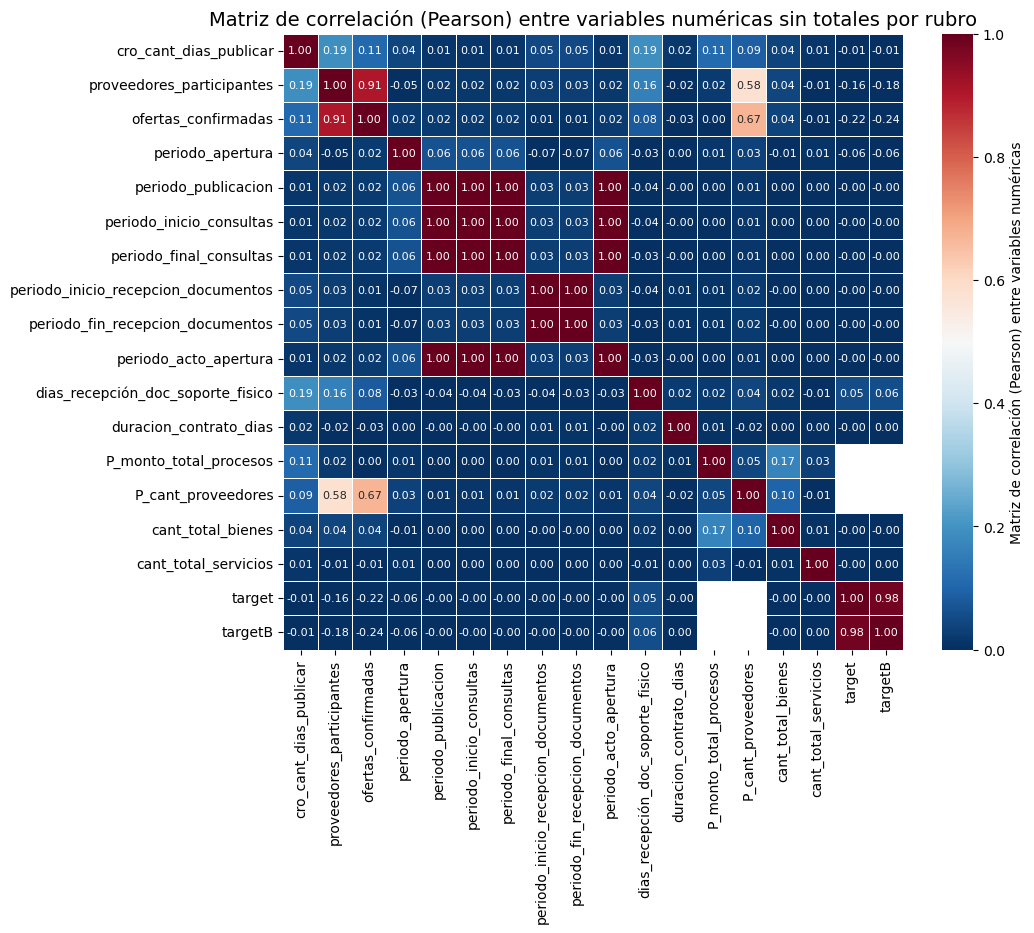

In [48]:
#ver si hay correlaciones entre estas variables
# Calcular la matriz de correlación (Pearson por defecto)
# Reemplazar el texto exacto 'sin datos' por 0
df_num_sin_tot = df_num_sin_tot.replace('sin datos', 0)
# Reemplaza valores pd.NA por np.nan
df_num_sin_tot = df_num_sin_tot.replace({pd.NA: np.nan})
corr = df_num_sin_tot.corr(method='pearson')


# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
corr_abs = corr.abs()
altas_corr = corr_abs[corr_abs > 0.0].dropna(how='all', axis=0).dropna(how='all', axis=1)
#sns.heatmap(altas_corr, annot=True, cmap='coolwarm')
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=0,         # Cramér's V va de 0 a 1
    vmax=1,
    cbar_kws={'label': "Matriz de correlación (Pearson) entre variables numéricas"}
)

plt.title("Matriz de correlación (Pearson) entre variables numéricas sin totales por rubro", fontsize=14)
plt.show()


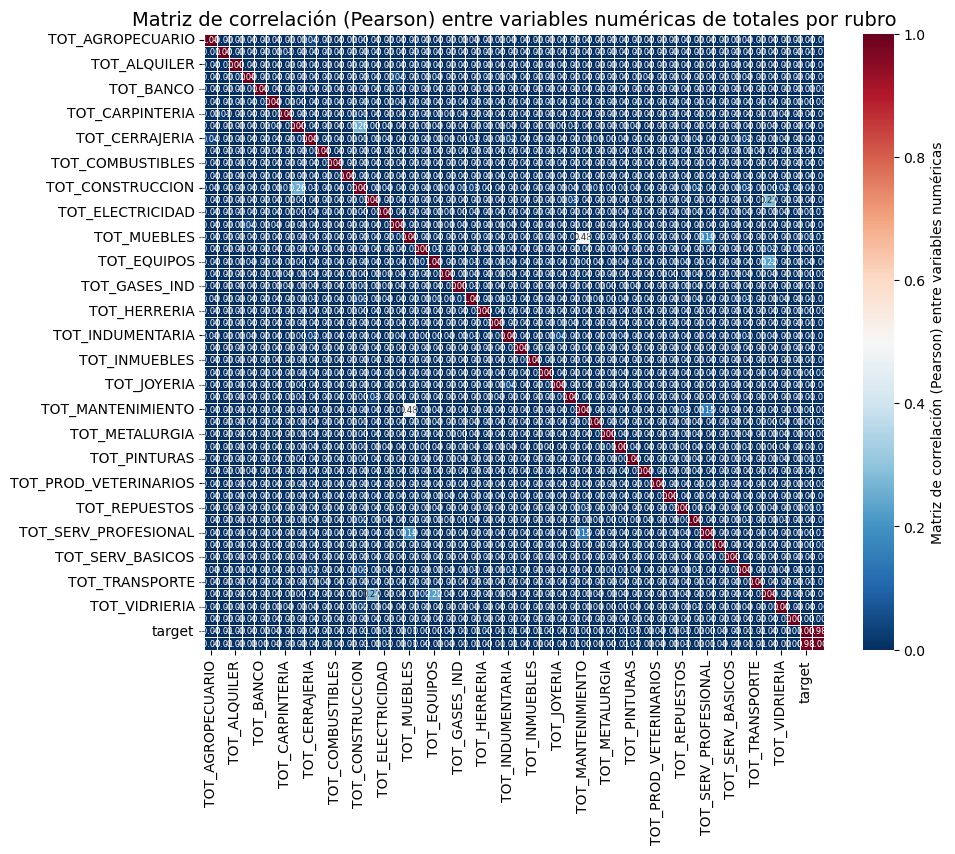

In [37]:
#ver si hay correlaciones entre estas variables
# Calcular la matriz de correlación (Pearson por defecto)
# Reemplazar el texto exacto 'sin datos' por 0
df_num_tot = df_num_tot.replace('sin datos', 0)
# Reemplaza valores pd.NA por np.nan
df_num_tot = df_num_tot.replace({pd.NA: np.nan})
corr = df_num_tot.corr(method='pearson')


# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
corr_abs = corr.abs()
altas_corr = corr_abs[corr_abs > 0.0].dropna(how='all', axis=0).dropna(how='all', axis=1)
#sns.heatmap(altas_corr, annot=True, cmap='coolwarm')
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    annot_kws={"size": 6},
    vmin=0,         # Cramér's V va de 0 a 1
    vmax=1,
    cbar_kws={'label': "Matriz de correlación (Pearson) entre variables numéricas"}
)

plt.title("Matriz de correlación (Pearson) entre variables numéricas de totales por rubro", fontsize=14)
plt.show()


### Matriz de asociación para analizar correlación entre variables categóricas

In [75]:
#Para analizar la relación entre variables categóricas se utiliza una matriz de asociación, 
#que cumple un rol similar al de una matriz de correlación. 
#Como medida de asociación se utiliza Cramer's V.

In [76]:
#Cramer's V es una medida de asociación para variables categóricas nominales basada en el estadístico chi-cuadrado. 
#Su valor varía entre 0 y 1, donde 0 indica ausencia de asociación y 1 indica asociación perfecta.
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

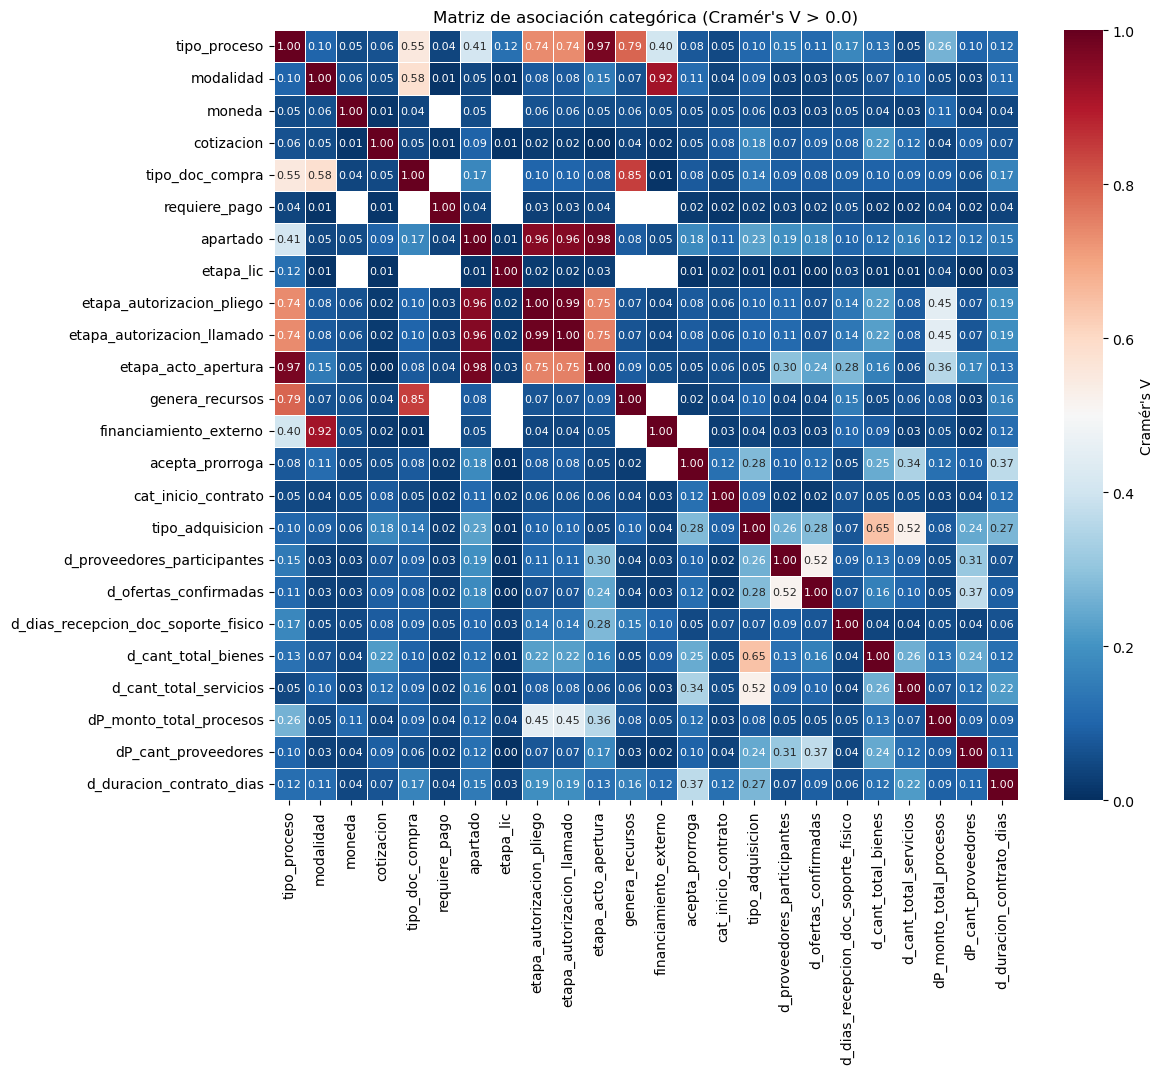

In [77]:

# Establecer el umbral de número de categorías permitido
umbral_categorias = 50  # Aquí puedes ajustar el valor a lo que consideres

# Filtrar las variables con menos de 'umbral_categorias' categorías
categoricas_filtradas = [
    col for col in df_cat.columns if df_cat[col].nunique() <= umbral_categorias
]

# Si después del filtrado, no hay suficientes variables, se podría lanzar un mensaje de advertencia
if len(categoricas_filtradas) < 2:
    print("Advertencia: Se han filtrado todas las variables categóricas debido a un número elevado de categorías.")

# Crear la matriz vacía para almacenar Cramér's V
matriz_cramers = pd.DataFrame(
    np.zeros((len(categoricas_filtradas), len(categoricas_filtradas))),
    index=categoricas_filtradas,
    columns=categoricas_filtradas
)

# Calcular la matriz de Cramér's V
for col1 in categoricas_filtradas:
    for col2 in categoricas_filtradas:
        matriz_cramers.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

# Asegurar tipo float
matriz_cramers = matriz_cramers.astype(float)

# Umbral
umbral = 0.0

# Filtrar valores por debajo del umbral
matriz_filtrada = matriz_cramers.where(matriz_cramers > umbral, np.nan)

# Graficar el heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_filtrada,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=0,         # Cramér's V va de 0 a 1
    vmax=1,
    cbar_kws={'label': "Cramér's V"}
)

plt.title(f"Matriz de asociación categórica (Cramér's V > {umbral})")
plt.show()


### Matriz de correlación para las métricas del grafo

In [49]:
#se agrega el target para ver si esta correlacionado con alguna métrica
df_target = df[['num_proceso','target', 'targetB']]
df_metricas = metricas.merge(df_target, on=["num_proceso"], how="left")
df_metricas=df_metricas.drop('num_proceso',axis=1)


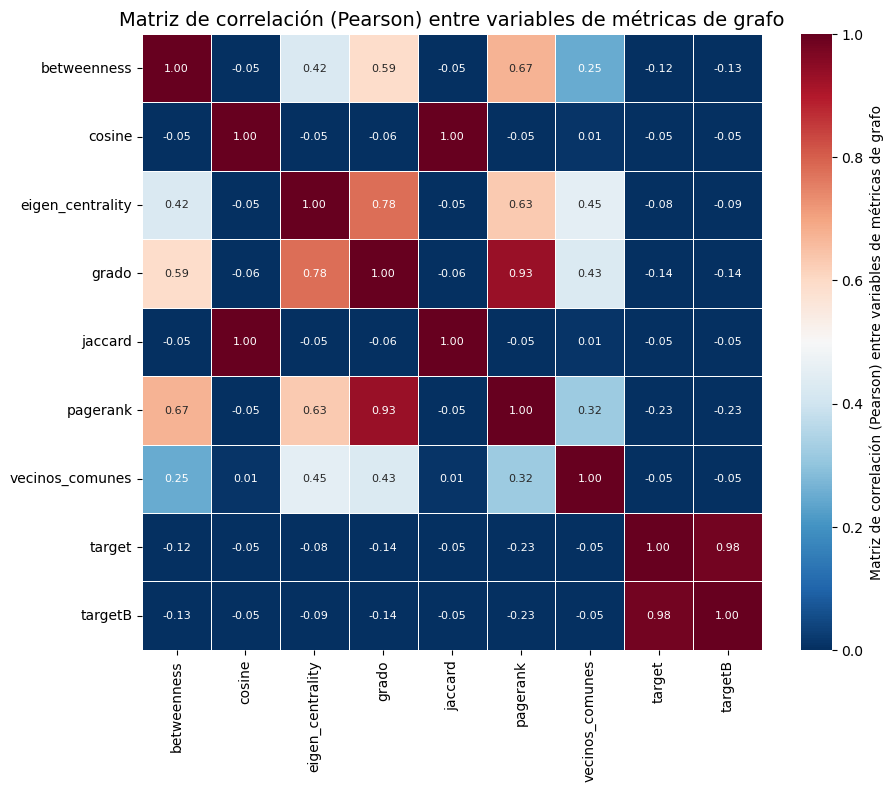

In [50]:
#ver si hay correlaciones entre estas variables
# Calcular la matriz de correlación (Pearson por defecto)
# Reemplazar el texto exacto 'sin datos' por 0
df_metricas = df_metricas.replace('sin datos', 0)
# Reemplaza valores pd.NA por np.nan
df_metricas = df_metricas.replace({pd.NA: np.nan})
corr = df_metricas.corr(method='pearson')


# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
corr_abs = corr.abs()
altas_corr = corr_abs[corr_abs > 0.0].dropna(how='all', axis=0).dropna(how='all', axis=1)
#sns.heatmap(altas_corr, annot=True, cmap='coolwarm')
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=0,         # Cramér's V va de 0 a 1
    vmax=1,
    cbar_kws={'label': "Matriz de correlación (Pearson) entre variables de métricas de grafo"}
)

plt.title("Matriz de correlación (Pearson) entre variables de métricas de grafo", fontsize=14)
plt.show()

#### Se arman conjuntos de train y test

In [51]:
periodo_entrenamiento = 202112  # Último mes de entrenamiento
# Definir el periodo de prueba entre enero de 2020 (202001) y diciembre de 2022 (202212)
periodo_prueba_inicio = 202201  # Primer mes de prueba
periodo_prueba_fin = 202212    # Último mes de prueba

In [52]:
# Filtrar los datos para entrenamiento (hasta diciembre de 2021)
df_train = df[df['periodo_apertura'] <= periodo_entrenamiento]

# Filtrar los datos para prueba (de enero de 2020 a diciembre de 2022)
df_test = df[(df['periodo_apertura'] >= periodo_prueba_inicio) & (df['periodo_apertura'] <= periodo_prueba_fin)]
# Verificar tamaños
print(f'Tamaño del conjunto de entrenamiento: {df_train.shape}')
print(f'Tamaño del conjunto de prueba: {df_test.shape}')

Tamaño del conjunto de entrenamiento: (55476, 93)
Tamaño del conjunto de prueba: (14210, 93)


In [53]:
# Contar cuántos casos hay de cada clase en la columna 'target'
print(df_train['target'].value_counts())


target
0    43005
2    11145
1     1326
Name: count, dtype: int64


In [54]:
# Contar cuántos casos hay de cada clase en la columna 'target'
print(df_test['target'].value_counts())

target
0    11557
2     2283
1      370
Name: count, dtype: int64


In [55]:
#se elimina de las variables los target
X_train= df_train.drop(columns=["target"])
X_train= X_train.drop(columns=["targetB"])
Y_train = df_train["target"]

X_test= df_test.drop(columns=["target"])
X_test= X_test.drop(columns=["targetB"])
Y_test = df_test["target"]

### Se construye un primer modelo para tener una primer mirada de los resultados

In [22]:
#Variables categóricas incluídas en el modelo
# Identificar columnas categóricas por nombre
cat_features = ['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion','d_proveedores_participantes','d_ofertas_confirmadas','d_dias_recepcion_doc_soporte_fisico','d_cant_total_bienes','d_cant_total_servicios','dP_monto_total_procesos','dP_cant_proveedores','d_duracion_contrato_dias']

In [57]:
#se reemplazan nulos con la etiqueta "sin datos" ya que el algoritmo no acepta nulos
X_train[cat_features] = X_train[cat_features].fillna("sin datos")
X_test[cat_features] = (X_test[cat_features].fillna("sin datos").infer_objects(copy=False))

In [50]:
#se aplica la combinación de parámetros
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    eval_metric='MultiClass',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)


In [68]:
# Crear pools de entrenamiento y test (recomendado para CatBoost)
train_pool = Pool(data=X_train, label=Y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=Y_test, cat_features=cat_features)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 1.0262733	test: 1.0265381	best: 1.0265381 (0)	total: 656ms	remaining: 10m 55s
100:	learn: 0.2191355	test: 0.2566728	best: 0.2566399 (99)	total: 1m 6s	remaining: 9m 53s
200:	learn: 0.1926984	test: 0.2503493	best: 0.2503493 (200)	total: 2m 27s	remaining: 9m 47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2503493426
bestIteration = 200

Shrink model to first 201 iterations.


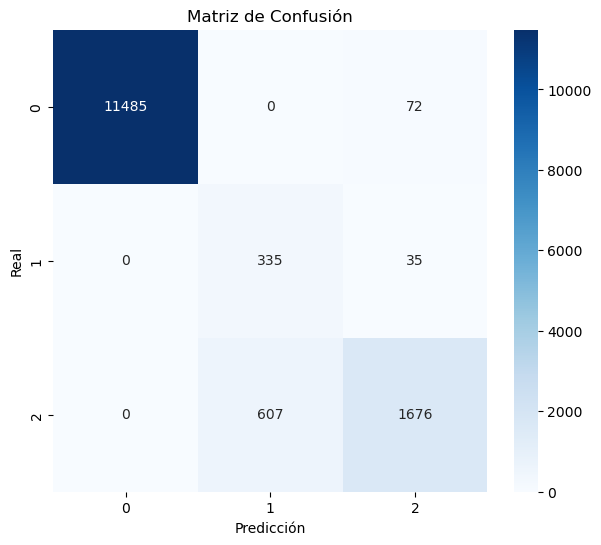

In [69]:
#se construye la matriz de confusión sobre el dataset de test
y_pred = model.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [70]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     11557
           1       0.36      0.91      0.51       370
           2       0.94      0.73      0.82      2283

    accuracy                           0.95     14210
   macro avg       0.77      0.88      0.78     14210
weighted avg       0.97      0.95      0.96     14210



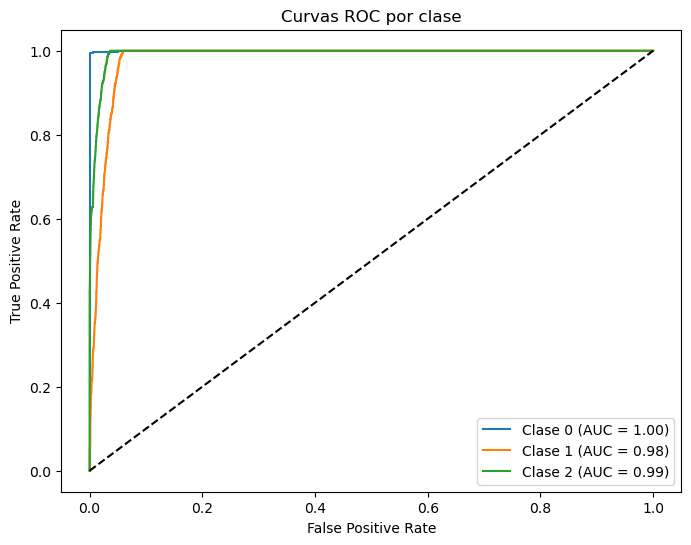

In [36]:
#se calcula la curva ROC
# Probabilidades
y_proba = model.predict_proba(X_test)

# Binarizar etiquetas para ROC multiclase
classes = np.unique(Y_test)
Y_test_bin = label_binarize(Y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curvas ROC por clase")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [71]:
#se calcula la importancia de las variables
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

df_importance.to_csv(ruta+"importancia_var_model1.csv")
print(df_importance)


                    feature  importance
19      ofertas_confirmadas   27.128634
89      dP_cant_proveedores   17.009142
88  dP_monto_total_procesos   16.385981
9                  apartado    3.907951
2          unidad_ejecutora    3.824948
..                      ...         ...
36            TOT_ART_HOGAR    0.000000
58          TOT_INFORMATICA    0.000000
67             TOT_PINTURAS    0.000000
64              TOT_METALES    0.000000
66              TOT_NAUTICA    0.000000

[91 rows x 2 columns]


In [25]:
#se quita ofertas confirmadas de las variables,porque si bien no aparece entre las variables correlacionadas
#se observa que siempre que el proceso de compra es desierto no tiene ofertas confirmadas. 
# y otras variables que permiten inferir el target

In [58]:
#se elimina de las variables ofertas confirmadas
X_train= X_train.drop(columns=["ofertas_confirmadas"])
X_test= X_test.drop(columns=["ofertas_confirmadas"])

X_train= X_train.drop(columns=["d_ofertas_confirmadas"])
X_test= X_test.drop(columns=["d_ofertas_confirmadas"])

X_train= X_train.drop(columns=["proveedores_participantes"])
X_test= X_test.drop(columns=["proveedores_participantes"])

X_train= X_train.drop(columns=["P_cant_proveedores"])
X_test= X_test.drop(columns=["P_cant_proveedores"])

X_train= X_train.drop(columns=["P_monto_total_procesos"])
X_test= X_test.drop(columns=["P_monto_total_procesos"])

X_train= X_train.drop(columns=["cant_total_servicios"])
X_test= X_test.drop(columns=["cant_total_servicios"])

X_train= X_train.drop(columns=["cant_total_bienes"])
X_test= X_test.drop(columns=["cant_total_bienes"])

X_train= X_train.drop(columns=["dP_monto_total_procesos"])
X_test= X_test.drop(columns=["dP_monto_total_procesos"])

X_train= X_train.drop(columns=["dP_cant_proveedores"])
X_test= X_test.drop(columns=["dP_cant_proveedores"])

X_train= X_train.drop(columns=["d_proveedores_participantes"])
X_test= X_test.drop(columns=["d_proveedores_participantes"])

#se arma el dataset solo con variables categóricas 

cat_features = ['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion','d_dias_recepcion_doc_soporte_fisico','d_cant_total_bienes','d_cant_total_servicios','d_duracion_contrato_dias']

### Modelo multitarget

#### Ponderador para clases desbalanceadas

In [59]:
#como las clases son desbalanceadas, se crea un ponderador para que el modelo intente clasificar los casos de las clases 1 y 2.

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

# Convertir a lista para poder modificarla
weights = list(weights)

# Multiplicador
factor = 1.1

# Multiplicar los pesos de las clases 1 y 2

class_labels = np.unique(Y_train)

for i, c in enumerate(class_labels):
    if c in [1, 2]:
        weights[i] *= factor

print(weights)

[0.4299965120334845, 15.34027149321267, 1.82514131897712]


#### Elegir la mejor combinación de parámetros 

In [54]:

train_pool = Pool(
    data=X_train,
    label=Y_train,
    cat_features=cat_features
)

model = CatBoostClassifier(
    loss_function='MultiClass',
    class_weights = weights, #auto_class_weights='Balanced',
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    thread_count=-1,
    verbose=50
)

param_dist = {
    'iterations': [1000, 1500],
    'learning_rate': [0.03, 0.05],
    'depth': [6, 8],
    'l2_leaf_reg': [ 3, 5, 10],
    'bagging_temperature': [0, 1],
    'border_count': [64, 128],
    'grow_policy': ['SymmetricTree'],
    'min_data_in_leaf': [1, 5, 20],
    'class_weights': [weights]
}

result = model.randomized_search(
    param_distributions=param_dist,
    X=train_pool,
    n_iter=10,          # mucho más rápido
    cv=3,               # reduce tiempo
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    stratified=True,
    verbose=50
)

best_model = model  # CatBoost actualiza el modelo con el mejor


Training on fold [0/3]
0:	learn: 1.0803722	test: 1.0807584	best: 1.0807584 (0)	total: 445ms	remaining: 7m 24s
50:	learn: 0.7615223	test: 0.7745774	best: 0.7745774 (50)	total: 17.7s	remaining: 5m 28s
100:	learn: 0.7078863	test: 0.7311285	best: 0.7311285 (100)	total: 38.7s	remaining: 5m 44s
150:	learn: 0.6803426	test: 0.7153148	best: 0.7153148 (150)	total: 59.6s	remaining: 5m 34s
200:	learn: 0.6636920	test: 0.7088007	best: 0.7088007 (200)	total: 1m 18s	remaining: 5m 13s
250:	learn: 0.6511880	test: 0.7046804	best: 0.7046442 (249)	total: 1m 38s	remaining: 4m 52s
300:	learn: 0.6397290	test: 0.7008802	best: 0.7008802 (300)	total: 1m 58s	remaining: 4m 35s
350:	learn: 0.6235492	test: 0.6977222	best: 0.6977222 (350)	total: 2m 19s	remaining: 4m 18s
400:	learn: 0.5913496	test: 0.6930598	best: 0.6930598 (400)	total: 2m 46s	remaining: 4m 8s
450:	learn: 0.5592781	test: 0.6886557	best: 0.6886557 (450)	total: 3m 14s	remaining: 3m 57s
500:	learn: 0.5329246	test: 0.6872080	best: 0.6869424 (476)	total: 3

In [55]:
best_model.get_params()

{'loss_function': 'MultiClass',
 'od_wait': 50,
 'od_type': 'Iter',
 'random_seed': 42,
 'verbose': 50,
 'class_weights': [0.4299965120334845, 139.45701357466064, 16.592193808882907],
 'border_count': 128,
 'iterations': 1000,
 'bagging_temperature': 0,
 'l2_leaf_reg': 3,
 'grow_policy': 'SymmetricTree',
 'depth': 6,
 'min_data_in_leaf': 5,
 'learning_rate': 0.03}

In [24]:
#se aplica la mejor combinación de parámetros encontrada
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    l2_leaf_reg=3,
    verbose=100,
    class_weights=[0.4299965120334845, 15.34027149321267, 1.82514131897712],
    border_count=128,
    bagging_temperature=0,
    grow_policy='SymmetricTree',
    min_data_in_leaf=5,
    od_wait=50,
    od_type='Iter'
)

In [25]:
#se reemplazan nulos con la etiqueta "sin datos" ya que el algoritmo no acepta nulos

X_train[cat_features] = X_train[cat_features].fillna("sin datos")
X_test[cat_features] = (X_test[cat_features].fillna("sin datos").infer_objects(copy=False))

In [26]:
# Crear pools de entrenamiento y test (recomendado para CatBoost)

train_pool = Pool(data=X_train, label=Y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=Y_test, cat_features=cat_features)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 1.0922042	test: 1.0946256	best: 1.0946256 (0)	total: 504ms	remaining: 8m 23s
100:	learn: 0.9366890	test: 1.0112145	best: 1.0112145 (100)	total: 32.4s	remaining: 4m 48s
200:	learn: 0.9075237	test: 0.9988555	best: 0.9988555 (200)	total: 1m 2s	remaining: 4m 8s
300:	learn: 0.8886060	test: 0.9924493	best: 0.9923688 (298)	total: 1m 32s	remaining: 3m 34s
400:	learn: 0.8699459	test: 0.9864941	best: 0.9864941 (400)	total: 2m 3s	remaining: 3m 4s
500:	learn: 0.8494540	test: 0.9797119	best: 0.9794372 (490)	total: 2m 35s	remaining: 2m 34s
600:	learn: 0.8339659	test: 0.9762994	best: 0.9762313 (597)	total: 3m 6s	remaining: 2m 3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9760359525
bestIteration = 606

Shrink model to first 607 iterations.


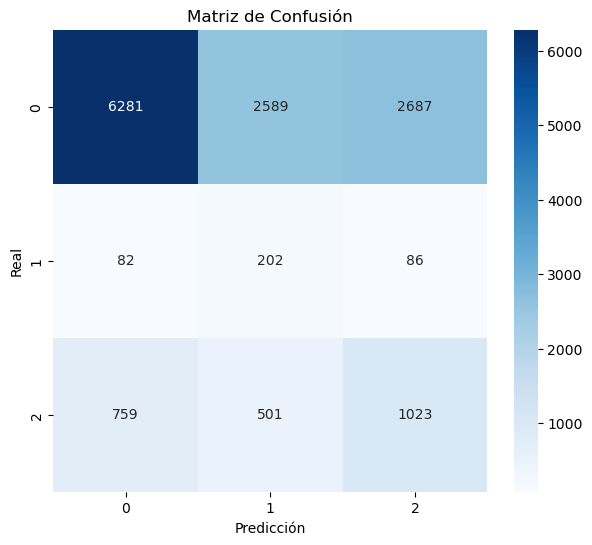

In [27]:
#se construye la matriz de confusión sobre el dataset de test

y_pred = model.predict(test_pool)
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [28]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.54      0.67     11557
           1       0.06      0.55      0.11       370
           2       0.27      0.45      0.34      2283

    accuracy                           0.53     14210
   macro avg       0.40      0.51      0.37     14210
weighted avg       0.76      0.53      0.60     14210



In [31]:
#se calcula la importancia de las variables
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

df_importance.to_csv(ruta+"importancia_var_modelCatM.csv")
print(df_importance)

                               feature  importance
9                             apartado   23.101195
2                     unidad_ejecutora   13.373012
3   servicio_administrativo_financiero    9.804315
78                 d_cant_total_bienes    4.944444
28                    tipo_adquisicion    3.763280
..                                 ...         ...
65               TOT_PROD_VETERINARIOS    0.000000
60                         TOT_METALES    0.000000
35                     TOT_CARPINTERIA    0.000000
8                        requiere_pago    0.000000
0                          num_proceso    0.000000

[81 rows x 2 columns]


In [30]:
df_importance.to_csv(ruta+'importanciaVar_cat_M.csv')

#### Se calculan las probabilidades para clase y se guarda el resultado en un archivo para ser usado en el ensamble

In [67]:
# Obtener probabilidades (3 clases)
pred_prob = model.predict(test_pool, prediction_type="Probability")

# Obtener clase predicha
y_pred = np.argmax(pred_prob, axis=1)

# Crear copia del dataframe test
df_test_pred = resultado.copy()

# Agregar clase predicha
df_test_pred["catM_pred_class"] = y_pred

# Agregar probabilidades por clase
df_test_pred["catM_prob_class_0"] = pred_prob[:, 0]
df_test_pred["catM_prob_class_1"] = pred_prob[:, 1]
df_test_pred["catM_prob_class_2"] = pred_prob[:, 2]

df_test_pred.head()
resultado = df_test_pred.copy()



In [68]:
resultado

,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,...,tipo_adquisicion,target,xgbM_pred_class,xgbM_prob_class_0,xgbM_prob_class_1,xgbM_prob_class_2,catM_pred_class,catM_prob_class_0,catM_prob_class_1,catM_prob_class_2
0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,BIEN,0,0,0.721647,0.003294,0.275058,2,0.411277,0.128503,0.460220
1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,BIEN,0,0,0.753516,0.002544,0.243940,2,0.445363,0.091018,0.463619
2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,...,MIXTO,0,0,0.809063,0.000722,0.190215,0,0.566070,0.075467,0.358463
3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,...,SERVICIO,0,0,0.587880,0.007950,0.404170,2,0.302707,0.252384,0.444909
4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,...,SERVICIO,0,0,0.777471,0.010338,0.212191,0,0.413068,0.342533,0.244399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,69681,0.0,202201,202201.0,202201.0,202201.0,NaN,NaN,202201.0,NaN,...,SERVICIO,1,1,0.234091,0.649601,0.116308,1,0.193922,0.719669,0.086409
14206,69682,0.0,202206,202206.0,202206.0,202206.0,NaN,NaN,202206.0,NaN,...,BIEN,1,0,0.703431,0.064074,0.232495,0,0.415175,0.176035,0.408791
14207,69683,0.0,202211,202211.0,202211.0,202211.0,NaN,NaN,202211.0,NaN,...,SERVICIO,1,0,0.453863,0.287520,0.258617,2,0.253769,0.353969,0.392261
14208,69684,0.0,202205,202205.0,202205.0,202205.0,NaN,NaN,202205.0,NaN,...,BIEN,1,0,0.478834,0.386554,0.134613,1,0.173172,0.636360,0.190468


In [69]:
resultado.to_csv(ruta+'resultado_cat_N.csv')

### Agregar variables de métricas de grafos

In [ ]:
df_propiedades_grafo = metricas

In [68]:
X_train_metricas = X_train.merge(df_propiedades_grafo, on="num_proceso", how="left")
X_test_metricas = X_test.merge(df_propiedades_grafo, on="num_proceso", how="left")


In [69]:
X_train_metricas[cat_features] = X_train_metricas[cat_features].fillna("sin_datos")
X_test_metricas[cat_features] = X_test_metricas[cat_features].fillna("sin_datos")

In [70]:
weights

[0.4299965120334845, 15.34027149321267, 1.82514131897712]

In [ ]:
train_pool = Pool(
    data=X_train_metricas,
    label=Y_train,
    cat_features=cat_features
)

model = CatBoostClassifier(
    loss_function='MultiClass',
    class_weights = weights, #auto_class_weights='Balanced',
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    thread_count=-1,
    verbose=50
)

param_dist = {
    'iterations': [1000, 1500],
    'learning_rate': [0.03, 0.05],
    'depth': [6, 8],
    'l2_leaf_reg': [ 3, 5, 10],
    'bagging_temperature': [0, 1],
    'border_count': [64, 128],
    'grow_policy': ['SymmetricTree'],
    'min_data_in_leaf': [1, 5, 20],
    'class_weights': [weights]
}

result = model.randomized_search(
    param_distributions=param_dist,
    X=train_pool,
    n_iter=10,          # mucho más rápido
    cv=3,               # reduce tiempo
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    stratified=True,
    verbose=50
)

best_model = model  # CatBoost actualiza el modelo con el mejor

In [50]:
best_model.get_params()

{'loss_function': 'MultiClass',
 'od_wait': 50,
 'od_type': 'Iter',
 'random_seed': 42,
 'verbose': 50,
 'class_weights': [0.4299965120334845, 15.34027149321267, 1.82514131897712],
 'border_count': 128,
 'iterations': 1000,
 'bagging_temperature': 0,
 'l2_leaf_reg': 3,
 'grow_policy': 'SymmetricTree',
 'depth': 6,
 'min_data_in_leaf': 5,
 'learning_rate': 0.03}

In [72]:
#se aplica la mejor combinación de parámetros encontrada
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    l2_leaf_reg=3,
    verbose=50,
    class_weights=[0.4299965120334845, 15.34027149321267, 1.82514131897712],
    border_count=128,
    bagging_temperature=0,
    grow_policy='SymmetricTree',
    min_data_in_leaf=5,
    od_wait=50,
    od_type='Iter'
)

In [73]:
# Crear pools de entrenamiento y test (recomendado para CatBoost)
train_pool = Pool(data=X_train_metricas, label=Y_train, cat_features=cat_features)
test_pool = Pool(data=X_test_metricas, label=Y_test, cat_features=cat_features)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 1.0790168	test: 1.0816040	best: 1.0816040 (0)	total: 345ms	remaining: 5m 44s
50:	learn: 0.7322385	test: 0.7807304	best: 0.7807304 (50)	total: 16.1s	remaining: 4m 58s
100:	learn: 0.6650808	test: 0.7298407	best: 0.7298407 (100)	total: 31.7s	remaining: 4m 41s
150:	learn: 0.6393845	test: 0.7170229	best: 0.7169377 (149)	total: 47.3s	remaining: 4m 25s
200:	learn: 0.6220693	test: 0.7060282	best: 0.7060282 (200)	total: 1m 2s	remaining: 4m 8s
250:	learn: 0.6098827	test: 0.7022261	best: 0.7022261 (250)	total: 1m 17s	remaining: 3m 52s
300:	learn: 0.5987261	test: 0.6977995	best: 0.6977995 (300)	total: 1m 34s	remaining: 3m 39s
350:	learn: 0.5869431	test: 0.6934237	best: 0.6930178 (347)	total: 1m 51s	remaining: 3m 25s
400:	learn: 0.5722463	test: 0.6870529	best: 0.6870353 (399)	total: 2m 8s	remaining: 3m 11s
450:	learn: 0.5561199	test: 0.6816343	best: 0.6815777 (449)	total: 2m 25s	remaining: 2m 56s
500:	learn: 0.5434791	test: 0.6780236	best: 0.6780236 (500)	total: 2m 41s	remaining: 2m 40s
5

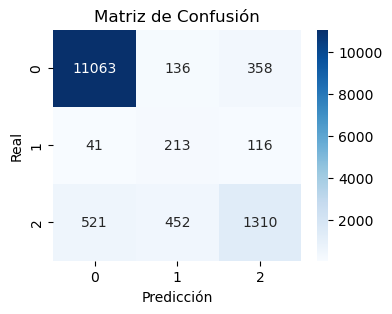

In [77]:
#se construye la matriz de confusión sobre el dataset de test
y_pred = model.predict(test_pool)
cm = confusion_matrix(Y_test, y_pred)

fmt_cm=[[f"{x:,}".replace(",",".") for x in row] for row in cm]

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [75]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95     11557
           1       0.27      0.58      0.36       370
           2       0.73      0.57      0.64      2283

    accuracy                           0.89     14210
   macro avg       0.65      0.70      0.65     14210
weighted avg       0.90      0.89      0.89     14210



In [76]:
#se calcula la importancia de las variables
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train_metricas.columns

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

df_importance.to_csv(ruta+"importancia_var_CatMetricas.csv")
print(df_importance)

                               feature  importance
84                               grado   25.080455
86                            pagerank   10.005020
9                             apartado    7.523478
2                     unidad_ejecutora    6.372062
3   servicio_administrativo_financiero    3.982635
..                                 ...         ...
38                            TOT_CINE    0.000000
40                       TOT_CONCESION    0.000000
60                         TOT_METALES    0.000000
57                         TOT_JOYERIA    0.000000
0                          num_proceso    0.000000

[88 rows x 2 columns]


In [57]:
# Obtener probabilidades (3 clases)
pred_prob = model.predict(test_pool, prediction_type="Probability")

# Obtener clase predicha
y_pred = np.argmax(pred_prob, axis=1)

# Crear copia del dataframe test
df_test_pred = resultado.copy()

# Agregar clase predicha
df_test_pred["catMMG_pred_class"] = y_pred

# Agregar probabilidades por clase
df_test_pred["catMMG_prob_class_0"] = pred_prob[:, 0]
df_test_pred["catMMG_prob_class_1"] = pred_prob[:, 1]
df_test_pred["catMMG_prob_class_2"] = pred_prob[:, 2]

df_test_pred.head()
resultado = df_test_pred.copy()

In [58]:
resultado

,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,...,xgbM_prob_class_1,xgbM_prob_class_2,catM_pred_class,catM_prob_class_0,catM_prob_class_1,catM_prob_class_2,catMMG_pred_class,catMMG_prob_class_0,catMMG_prob_class_1,catMMG_prob_class_2
0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,0.003294,0.275058,0,0.498254,0.098193,0.403553,0,0.775085,0.055235,0.169681
1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,0.002544,0.243940,0,0.537650,0.070808,0.391542,0,0.841083,0.024616,0.134302
2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,...,0.000722,0.190215,0,0.616584,0.066081,0.317335,0,0.769811,0.013453,0.216736
3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,...,0.007950,0.404170,2,0.338180,0.254758,0.407062,0,0.892983,0.029351,0.077667
4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,...,0.010338,0.212191,0,0.488870,0.303400,0.207730,0,0.927871,0.038998,0.033131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,69681,0.0,202201,202201.0,202201.0,202201.0,NaN,NaN,202201.0,NaN,...,0.649601,0.116308,1,0.220694,0.707353,0.071953,1,0.010537,0.918119,0.071345
14206,69682,0.0,202206,202206.0,202206.0,202206.0,NaN,NaN,202206.0,NaN,...,0.064074,0.232495,0,0.492776,0.137297,0.369927,2,0.020308,0.319817,0.659874
14207,69683,0.0,202211,202211.0,202211.0,202211.0,NaN,NaN,202211.0,NaN,...,0.287520,0.258617,2,0.311300,0.318802,0.369897,2,0.007799,0.461462,0.530739
14208,69684,0.0,202205,202205.0,202205.0,202205.0,NaN,NaN,202205.0,NaN,...,0.386554,0.134613,1,0.212031,0.628849,0.159120,1,0.006795,0.590800,0.402404


In [60]:
resultado.to_csv(ruta+'resultado_cat.csv')

### Target binario

In [62]:
Y_train= Y_train.replace({2: 1})
Y_test= Y_test.replace({2: 1})

In [63]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

weights = list(weights)
print(weights)

[0.6449947680502267, 2.2242001443348567]


In [64]:

train_pool = Pool(
    data=X_train,
    label=Y_train,
    cat_features=cat_features
)

model = CatBoostClassifier(
    loss_function='Logloss',         # target binario
    class_weights=weights,           
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    thread_count=-1,
    verbose=50
)

param_dist = {
    'iterations': [1000, 1500],
    'learning_rate': [0.03, 0.05],
    'depth': [6, 8],
    'l2_leaf_reg': [3, 5, 10],
    'bagging_temperature': [0, 1],
    'border_count': [64, 128],
    'grow_policy': ['SymmetricTree'],
    'min_data_in_leaf': [1, 5, 20],
    'class_weights': [weights]       # pesos binarios
}

result = model.randomized_search(
    param_distributions=param_dist,
    X=train_pool,
    n_iter=10,
    cv=3,
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    stratified=True,
    verbose=50
)

best_model = model

Training on fold [0/3]
0:	learn: 0.6912692	test: 0.6911095	best: 0.6911095 (0)	total: 298ms	remaining: 4m 57s
50:	learn: 0.6453358	test: 0.6458003	best: 0.6458003 (50)	total: 11.6s	remaining: 3m 36s
100:	learn: 0.6312846	test: 0.6366325	best: 0.6366325 (100)	total: 23.6s	remaining: 3m 29s
150:	learn: 0.6231367	test: 0.6332164	best: 0.6332164 (150)	total: 33.4s	remaining: 3m 7s
200:	learn: 0.6170421	test: 0.6311457	best: 0.6311457 (200)	total: 43.5s	remaining: 2m 52s
250:	learn: 0.6117040	test: 0.6296739	best: 0.6296739 (250)	total: 52.7s	remaining: 2m 37s
300:	learn: 0.6064598	test: 0.6283503	best: 0.6283503 (300)	total: 1m 2s	remaining: 2m 24s
350:	learn: 0.6007174	test: 0.6270490	best: 0.6270490 (350)	total: 1m 12s	remaining: 2m 13s
400:	learn: 0.5931920	test: 0.6260378	best: 0.6260378 (400)	total: 1m 22s	remaining: 2m 3s
450:	learn: 0.5865983	test: 0.6253929	best: 0.6253929 (450)	total: 1m 32s	remaining: 1m 52s
500:	learn: 0.5797468	test: 0.6246753	best: 0.6246753 (500)	total: 1m 42

In [65]:
best_model.get_params()

{'loss_function': 'Logloss',
 'od_wait': 50,
 'od_type': 'Iter',
 'random_seed': 42,
 'verbose': 50,
 'class_weights': [0.6449947680502267, 2.2242001443348567],
 'border_count': 128,
 'iterations': 1500,
 'bagging_temperature': 1,
 'l2_leaf_reg': 10,
 'grow_policy': 'SymmetricTree',
 'depth': 6,
 'min_data_in_leaf': 20,
 'learning_rate': 0.03}

In [66]:
#se aplica la mejor combinación de parámetros encontrada
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    l2_leaf_reg=10,
    verbose=50,
    class_weights=[0.6449947680502267, 2.2242001443348567],
    border_count=128,
    bagging_temperature=1,
    grow_policy='SymmetricTree',
    min_data_in_leaf=20,
    od_wait=50,
    od_type='Iter'
)

In [67]:
#se reemplazan nulos con la etiqueta "sin datos" ya que el algoritmo no acepta nulos
X_train[cat_features] = X_train[cat_features].fillna("sin datos")
X_test[cat_features] = (X_test[cat_features].fillna("sin datos").infer_objects(copy=False))

In [68]:
# Crear pools de entrenamiento y test (recomendado para CatBoost)
train_pool = Pool(data=X_train, label=Y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=Y_test, cat_features=cat_features)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 0.6910816	test: 0.6908405	best: 0.6908405 (0)	total: 191ms	remaining: 4m 45s
50:	learn: 0.6499670	test: 0.6465722	best: 0.6465722 (50)	total: 9.53s	remaining: 4m 30s
100:	learn: 0.6395762	test: 0.6375607	best: 0.6375607 (100)	total: 18.8s	remaining: 4m 19s
150:	learn: 0.6345399	test: 0.6337515	best: 0.6337515 (150)	total: 27.3s	remaining: 4m 4s
200:	learn: 0.6311774	test: 0.6320912	best: 0.6320868 (198)	total: 35.7s	remaining: 3m 50s
250:	learn: 0.6286609	test: 0.6312633	best: 0.6312633 (250)	total: 44.2s	remaining: 3m 40s
300:	learn: 0.6259792	test: 0.6304540	best: 0.6304310 (294)	total: 53.1s	remaining: 3m 31s
350:	learn: 0.6235635	test: 0.6297707	best: 0.6297707 (350)	total: 1m 2s	remaining: 3m 23s
400:	learn: 0.6207527	test: 0.6290712	best: 0.6290712 (400)	total: 1m 10s	remaining: 3m 13s
450:	learn: 0.6176698	test: 0.6283691	best: 0.6283691 (450)	total: 1m 19s	remaining: 3m 4s
500:	learn: 0.6148367	test: 0.6283010	best: 0.6281463 (486)	total: 1m 28s	remaining: 2m 55s
Stop

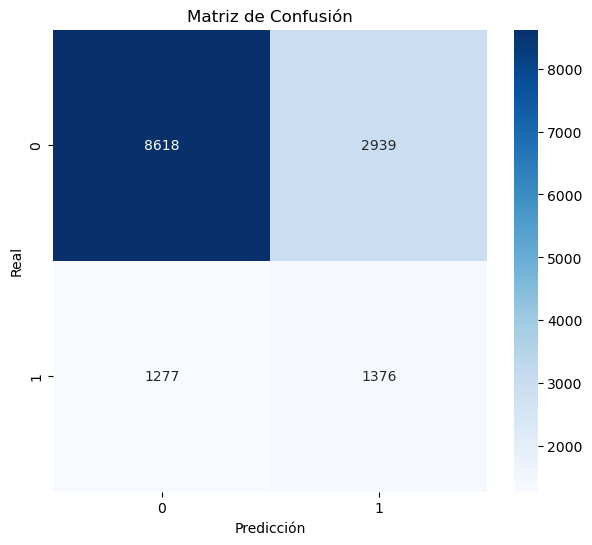

In [69]:
#se construye la matriz de confusión sobre el dataset de test
y_pred = model.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [70]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.75      0.80     11557
           1       0.32      0.52      0.39      2653

    accuracy                           0.70     14210
   macro avg       0.59      0.63      0.60     14210
weighted avg       0.77      0.70      0.73     14210



In [71]:
#se calcula la importancia de las variables
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

df_importance.to_csv(ruta+"importancia_var_modelBinario.csv")
print(df_importance)

                               feature  importance
2                     unidad_ejecutora   14.467733
78                 d_cant_total_bienes    9.577842
9                             apartado    9.181798
3   servicio_administrativo_financiero    8.139461
44                        TOT_LIMPIEZA    3.030300
..                                 ...         ...
46                  TOT_EQUIPO_MILITAR    0.000000
15              financiamiento_externo    0.000000
14                     genera_recursos    0.000000
8                        requiere_pago    0.000000
0                          num_proceso    0.000000

[81 rows x 2 columns]


In [72]:
# Obtener probabilidades (binario con 2 columnas)
pred_prob = model.predict(test_pool, prediction_type="Probability")  
# pred_prob.shape = (14210, 2)

# Clase positiva = columna 1
y_pred = (pred_prob[:, 1] > 0.5).astype(int)

# Copiar dataframe
df_test_pred = resultado.copy()

# Agregar clase predicha
df_test_pred["catB_pred_class"] = y_pred

# Probabilidad clase 1 (positiva)
df_test_pred["catB_prob_class_1"] = pred_prob[:, 1]

# Probabilidad clase 0 (negativa)
df_test_pred["catB_prob_class_0"] = pred_prob[:, 0]
resultado = df_test_pred.copy()

In [350]:
df_test_pred

,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,dias_recepción_doc_soporte_fisico,...,catM_prob_class_2,catMMG_prob_class_0,catMMG_prob_class_1,catMMG_prob_class_2,catB_pred_class,catB_prob_class_1,catB_prob_class_0,catBMG_pred_class,catBMG_prob_class_1,catBMG_prob_class_0
0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,0.357374,0.764883,0.054316,0.180801,0,0.384456,0.615544,0,0.156905,0.843095
1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,NaN,...,0.358718,0.831931,0.023986,0.144084,0,0.387231,0.612769,0,0.113881,0.886119
2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,NaN,...,0.279639,0.759036,0.020138,0.220827,0,0.276112,0.723888,0,0.096112,0.903888
3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,NaN,...,0.380300,0.880800,0.032583,0.086617,0,0.486975,0.513025,0,0.060587,0.939413
4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,NaN,...,0.169421,0.927968,0.038117,0.033915,0,0.345004,0.654996,0,0.020071,0.979929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,69681,0.0,202201,202201.0,202201.0,202201.0,NaN,NaN,202201.0,NaN,...,0.072260,0.011623,0.898031,0.090346,0,0.378961,0.621039,1,0.969404,0.030596
14206,69682,0.0,202206,202206.0,202206.0,202206.0,NaN,NaN,202206.0,NaN,...,0.341902,0.021317,0.325865,0.652818,0,0.381410,0.618590,1,0.970707,0.029293
14207,69683,0.0,202211,202211.0,202211.0,202211.0,NaN,NaN,202211.0,NaN,...,0.365833,0.009996,0.414924,0.575080,1,0.522150,0.477850,1,0.996322,0.003678
14208,69684,0.0,202205,202205.0,202205.0,202205.0,NaN,NaN,202205.0,NaN,...,0.204929,0.007545,0.677730,0.314726,0,0.493989,0.506011,1,0.991565,0.008435


In [ ]:
resultado.to_csv(ruta+'resultado_binario.csv')